In [ ]:
# =============================================================================
# HÜCRE 1: ORTAM KURULUMU VE H100 GPU YAPILANDIRMASI
# =============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import mixed_precision
from google.colab import drive

print("=" * 60)
print("   H100 OPTİMİZELİ EĞİTİM ORTAMI BAŞLATILIYOR")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. GOOGLE DRIVE BAĞLANTISI
# -----------------------------------------------------------------------------
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
print("✅ Google Drive bağlandı.")

# -----------------------------------------------------------------------------
# 2. H100 GPU KONTROLÜ VE MEMORY GROWTH
# -----------------------------------------------------------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Aktif: {len(gpus)} adet")
        for i, gpu in enumerate(gpus):
            details = tf.config.experimental.get_device_details(gpu)
            print(f"   -> GPU {i}: {details.get('device_name', 'Bilinmiyor')}")
    except RuntimeError as e:
        print(f"⚠️ GPU Ayar Hatası: {e}")
else:
    print("⚠️ GPU Bulunamadı! CPU ile devam ediliyor.")

# -----------------------------------------------------------------------------
# 3. MIXED PRECISION (H100 BF16) — H100'de BF16, A100'de float16'dan daha stabil
# -----------------------------------------------------------------------------
mixed_precision.set_global_policy('mixed_bfloat16')
print(f"✅ Mixed Precision Politikası: {mixed_precision.global_policy().name}")
print("   -> H100 Tensor Core'ları BF16 ile tam kapasitede kullanılacak.")

# -----------------------------------------------------------------------------
# 4. TensorFlow XLA JIT DERLEME (Hesapları GPU Graph'e fuse eder, ~%20 hız kazanımı)
# -----------------------------------------------------------------------------
tf.config.optimizer.set_jit(True)
print("✅ XLA JIT Derleme: AKTİF")

# -----------------------------------------------------------------------------
# 5. GLOBAL SABİTLER
# -----------------------------------------------------------------------------
ROOT_PATH       = '/content/drive/MyDrive/wifi_mqtt'
TIME_STEPS      = 20       # Zaman penceresi (Optuna'da test edilmişti)
TEST_SIZE       = 0.20     # %20 validation
BATCH_SIZE      = 8192     # H100'de büyük batch daha verimli (A100'deki 2048'den 4x büyük)
MAX_EPOCHS      = 300      # Early stopping zaten durduracak
PCA_VARIANCE    = 0.95     # Hedef varyans oranı (bileşen sayısı otomatik belirlenecek)
SEED            = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("\n📋 GLOBAL SABİTLER:")
print(f"   ROOT_PATH    : {ROOT_PATH}")
print(f"   TIME_STEPS   : {TIME_STEPS}")
print(f"   BATCH_SIZE   : {BATCH_SIZE}  (H100 optimizeli)")
print(f"   MAX_EPOCHS   : {MAX_EPOCHS}")
print(f"   PCA_VARIANCE : {PCA_VARIANCE*100:.0f}%  (bileşen sayısı otomatik)")

# -----------------------------------------------------------------------------
# 6. TF VERSİYON BİLGİSİ
# -----------------------------------------------------------------------------
print(f"\n✅ TensorFlow Versiyon : {tf.__version__}")
print(f"✅ NumPy Versiyon      : {np.__version__}")
print(f"✅ Pandas Versiyon     : {pd.__version__}")

print("\n" + "=" * 60)
print("   ORTAM HAZIR — HÜCRE 2'YE GEÇEBİLİRSİNİZ")
print("=" * 60)

   H100 OPTİMİZELİ EĞİTİM ORTAMI BAŞLATILIYOR
Mounted at /content/drive
✅ Google Drive bağlandı.
✅ GPU Aktif: 1 adet
   -> GPU 0: NVIDIA H100 80GB HBM3
✅ Mixed Precision Politikası: mixed_bfloat16
   -> H100 Tensor Core'ları BF16 ile tam kapasitede kullanılacak.
✅ XLA JIT Derleme: AKTİF

📋 GLOBAL SABİTLER:
   ROOT_PATH    : /content/drive/MyDrive/wifi_mqtt
   TIME_STEPS   : 20
   BATCH_SIZE   : 8192  (H100 optimizeli)
   MAX_EPOCHS   : 300
   PCA_VARIANCE : 95%  (bileşen sayısı otomatik)

✅ TensorFlow Versiyon : 2.19.0
✅ NumPy Versiyon      : 2.0.2
✅ Pandas Versiyon     : 2.2.2

   ORTAM HAZIR — HÜCRE 2'YE GEÇEBİLİRSİNİZ


   VERİ HAZIRLAMA AŞAMASI BAŞLATILIYOR

📂 Normal (Profiling) dosyaları taranıyor...
   -> Bulunan toplam dosya: 42

⏳ Dosyalar yükleniyor...
   -> Ham veri boyutu: (389956, 45)

🧹 Veri temizleniyor...
   -> Silinen sabit kolonlar (5 adet): ['Drate', 'Telnet', 'SMTP', 'SSH', 'IRC']
   -> Temizleme sonrası boyut: (389956, 40)
   -> Kullanılacak özellik sayısı: 40

⚖️ StandardScaler uygulanıyor...
   -> Scaler kaydedildi: central_scaler.pkl

🔬 PCA Varyans Analizi yapılıyor (Hedef: %95)...
   -> %95 varyans için gereken bileşen sayısı: 20
   -> Eski sabit değer (15) yerine 20 bileşen kullanılacak


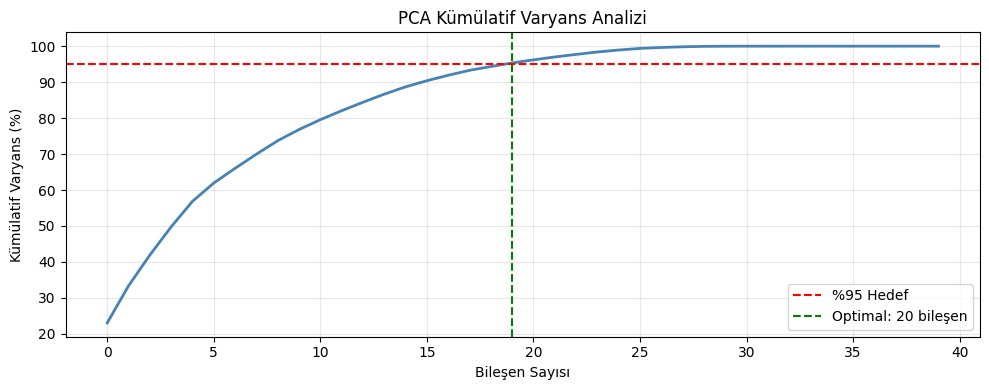

   -> PCA kaydedildi: central_pca.pkl

📊 ÖZET:
   -> PCA sonrası veri boyutu : (389956, 20)
   -> Açıklanan varyans       : %95.34
   -> PCA_COMPONENTS (yeni)   : 20

   HÜCRE 2 TAMAMLANDI — HÜCRE 3'E GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# HÜCRE 2: VERİ YÜKLEME, TEMİZLEME, SCALING VE OTOMATİK PCA
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("=" * 60)
print("   VERİ HAZIRLAMA AŞAMASI BAŞLATILIYOR")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. NORMAL (PROFİLİNG) DOSYALARINI TARA
# -----------------------------------------------------------------------------
print("\n📂 Normal (Profiling) dosyaları taranıyor...")
all_benign_files = []
for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv") and 'profiling' in root.lower():
            all_benign_files.append(os.path.join(root, file))

print(f"   -> Bulunan toplam dosya: {len(all_benign_files)}")

# -----------------------------------------------------------------------------
# 2. DOSYALARI YÜKLE VE BİRLEŞTİR
# -----------------------------------------------------------------------------
print("\n⏳ Dosyalar yükleniyor...")
dfs = []
for f in all_benign_files:
    try:
        df = pd.read_csv(f)
        df = df.select_dtypes(include=[np.number])
        df = df.astype('float32')
        dfs.append(df)
    except Exception as e:
        print(f"   ⚠️ Atlandı ({os.path.basename(f)}): {e}")

df_central = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f"   -> Ham veri boyutu: {df_central.shape}")

# -----------------------------------------------------------------------------
# 3. TEMİZLEME
# -----------------------------------------------------------------------------
print("\n🧹 Veri temizleniyor...")

# Sonsuz değerleri NaN yap, sonra düşür
df_central.replace([np.inf, -np.inf], np.nan, inplace=True)
df_central.dropna(inplace=True)

# Sıfır varyanslı (sabit) kolonları sil — model için anlamsız
varyanslar = df_central.var()
sifir_varyansli_kolonlar = varyanslar[varyanslar == 0].index.tolist()
df_central.drop(columns=sifir_varyansli_kolonlar, inplace=True)

print(f"   -> Silinen sabit kolonlar ({len(sifir_varyansli_kolonlar)} adet): {sifir_varyansli_kolonlar}")
print(f"   -> Temizleme sonrası boyut: {df_central.shape}")

# Kolon isimlerini sakla (test aşamasında alignment için kullanacağız)
FEATURE_COLUMNS = df_central.columns.tolist()
print(f"   -> Kullanılacak özellik sayısı: {len(FEATURE_COLUMNS)}")

# -----------------------------------------------------------------------------
# 4. STANDARD SCALING
# -----------------------------------------------------------------------------
print("\n⚖️ StandardScaler uygulanıyor...")
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_central)

# Scaler'ı kaydet
joblib.dump(scaler, 'central_scaler.pkl')
print(f"   -> Scaler kaydedildi: central_scaler.pkl")

# -----------------------------------------------------------------------------
# 5. OTOMATİK PCA — %95 VARYANS HEDEFİ
# -----------------------------------------------------------------------------
print(f"\n🔬 PCA Varyans Analizi yapılıyor (Hedef: %{PCA_VARIANCE*100:.0f})...")

# Önce tam PCA fit et — kaç bileşen gerektiğini öğrenmek için
pca_full = PCA(random_state=SEED)
pca_full.fit(scaled_data)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_optimal = int(np.argmax(cumulative_variance >= PCA_VARIANCE) + 1)

print(f"   -> %95 varyans için gereken bileşen sayısı: {n_components_optimal}")
print(f"   -> Eski sabit değer (15) yerine {n_components_optimal} bileşen kullanılacak")

# Varyans grafiği
plt.figure(figsize=(10, 4))
plt.plot(cumulative_variance * 100, linewidth=2, color='steelblue')
plt.axhline(y=95, color='red', linestyle='--', label='%95 Hedef')
plt.axvline(x=n_components_optimal - 1, color='green', linestyle='--',
            label=f'Optimal: {n_components_optimal} bileşen')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Varyans (%)')
plt.title('PCA Kümülatif Varyans Analizi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Şimdi optimal bileşen sayısıyla gerçek PCA'yı kur
pca = PCA(n_components=n_components_optimal, random_state=SEED)
pca_data = pca.fit_transform(scaled_data)

# PCA'yı kaydet
joblib.dump(pca, 'central_pca.pkl')
print(f"   -> PCA kaydedildi: central_pca.pkl")

# Global olarak güncelle
PCA_COMPONENTS = n_components_optimal

# RAM temizliği
del scaled_data, df_central, pca_full
gc.collect()

print(f"\n📊 ÖZET:")
print(f"   -> PCA sonrası veri boyutu : {pca_data.shape}")
print(f"   -> Açıklanan varyans       : %{cumulative_variance[n_components_optimal-1]*100:.2f}")
print(f"   -> PCA_COMPONENTS (yeni)   : {PCA_COMPONENTS}")

print("\n" + "=" * 60)
print("   HÜCRE 2 TAMAMLANDI — HÜCRE 3'E GEÇEBİLİRSİNİZ")
print("=" * 60)

In [ ]:
# =============================================================================
# HÜCRE 3: SEQUENCE OLUŞTURMA VE TRAIN/VAL SPLIT
# =============================================================================

import numpy as np
import gc

print("=" * 60)
print("   SEQUENCE OLUŞTURMA VE VERİ BÖLME")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. SEQUENCE (ZAMAN PENCERESİ) OLUŞTURMA
# H100 için: np.lib.stride_tricks ile sıfır kopya, maksimum hız
# -----------------------------------------------------------------------------
print(f"\n⏳ Zaman pencereleri oluşturuluyor (TIME_STEPS={TIME_STEPS})...")

def create_sequences_fast(data, time_steps):
    """
    np.lib.stride_tricks kullanarak sıfır kopya (zero-copy) sequence oluşturur.
    Klasik for döngüsüne göre ~10x daha hızlı ve RAM dostu.
    """
    n_samples = data.shape[0] - time_steps
    n_features = data.shape[1]

    shape   = (n_samples, time_steps, n_features)
    strides = (data.strides[0], data.strides[0], data.strides[1])

    sequences = np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides)
    # as_strided view döndürür, kopyasını alarak belleği güvenli hale getiriyoruz
    return np.array(sequences, dtype=np.float32)

X_all = create_sequences_fast(pca_data, TIME_STEPS)

# pca_data artık gerekmez
del pca_data
gc.collect()

print(f"   -> Toplam sequence boyutu: {X_all.shape}")
print(f"   -> Bellek kullanımı      : {X_all.nbytes / 1e6:.1f} MB")

# -----------------------------------------------------------------------------
# 2. KRONOLOJİK TRAIN / VAL SPLIT (ZAMAN SIZINTISI YOK)
# shuffle=False — zaman serisi verisinde karıştırma yapılmaz!
# -----------------------------------------------------------------------------
print(f"\n✂️ Kronolojik Train/Val bölmesi yapılıyor (%{int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)})...")

split_idx = int(len(X_all) * (1 - TEST_SIZE))

X_train = X_all[:split_idx]
X_val   = X_all[split_idx:]

del X_all
gc.collect()

print(f"   -> X_train boyutu: {X_train.shape}")
print(f"   -> X_val   boyutu: {X_val.shape}")

# -----------------------------------------------------------------------------
# 3. H100 İÇİN tf.data PIPELINE OLUŞTURMA
# Ham numpy yerine tf.data kullanmak:
#   - Prefetch ile GPU boşta kalmaz
#   - cache() ile RAM'den tekrar okuma yapılmaz
#   - drop_remainder=True ile sabit batch boyutu XLA'yı mutlu eder
# -----------------------------------------------------------------------------
import tensorflow as tf

print(f"\n⚡ H100 için tf.data pipeline kuruluyor (batch={BATCH_SIZE})...")

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, X_train))  # autoencoder: girdi=çıktı
    .cache()                                                  # ilk epoch'tan sonra RAM'de tut
    .shuffle(buffer_size=20000, seed=SEED)                   # her epoch farklı sıra
    .batch(BATCH_SIZE, drop_remainder=True)                  # sabit batch → XLA dostu
    .prefetch(AUTOTUNE)                                       # GPU hesaplarken CPU veri hazırlar
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, X_val))
    .cache()
    .batch(BATCH_SIZE, drop_remainder=False)
    .prefetch(AUTOTUNE)
)

print(f"   -> Train batch sayısı : {len(train_dataset)}")
print(f"   -> Val   batch sayısı : {len(val_dataset)}")

# -----------------------------------------------------------------------------
# 4. KONTROL
# -----------------------------------------------------------------------------
for batch_x, batch_y in train_dataset.take(1):
    print(f"\n✅ Örnek batch kontrolü:")
    print(f"   -> batch_x shape : {batch_x.shape}")
    print(f"   -> batch_y shape : {batch_y.shape}")
    print(f"   -> dtype         : {batch_x.dtype}")

print("\n" + "=" * 60)
print("   HÜCRE 3 TAMAMLANDI — HÜCRE 4'E GEÇEBİLİRSİNİZ")
print("=" * 60)

   SEQUENCE OLUŞTURMA VE VERİ BÖLME

⏳ Zaman pencereleri oluşturuluyor (TIME_STEPS=20)...
   -> Toplam sequence boyutu: (389936, 20, 20)
   -> Bellek kullanımı      : 623.9 MB

✂️ Kronolojik Train/Val bölmesi yapılıyor (%80/20)...
   -> X_train boyutu: (311948, 20, 20)
   -> X_val   boyutu: (77988, 20, 20)

⚡ H100 için tf.data pipeline kuruluyor (batch=8192)...
   -> Train batch sayısı : 38
   -> Val   batch sayısı : 10

✅ Örnek batch kontrolü:
   -> batch_x shape : (8192, 20, 20)
   -> batch_y shape : (8192, 20, 20)
   -> dtype         : <dtype: 'float32'>

   HÜCRE 3 TAMAMLANDI — HÜCRE 4'E GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# HÜCRE 4: MULTI-HEAD ATTENTION + LSTM HİBRİT MODEL MİMARİSİ (KERAS 3 UYUMLU)
# =============================================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add, TimeDistributed, Conv1D,
    Bidirectional, Lambda
)
from tensorflow.keras.optimizers import Adam

print("=" * 60)
print("   MODEL MİMARİSİ KURULUYOR")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. COMBINED LOSS FONKSİYONU (MAE + MSE)
# -----------------------------------------------------------------------------
def combined_reconstruction_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * mae + 0.4 * mse

# -----------------------------------------------------------------------------
# 2. TRANSFORMER ENCODER BLOĞU (Pre-LayerNorm)
# -----------------------------------------------------------------------------
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim, dropout_rate, name_prefix=""):
    # Multi-Head Self-Attention
    attn_input = LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln1")(x)
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout_rate,
        name=f"{name_prefix}_mha"
    )(attn_input, attn_input)
    x = Add(name=f"{name_prefix}_add1")([x, attn_output])

    # Feed-Forward
    ff_input = LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln2")(x)
    ff_output = Dense(ff_dim, activation='gelu', name=f"{name_prefix}_ff1")(ff_input)
    ff_output = Dropout(dropout_rate, name=f"{name_prefix}_drop")(ff_output)
    ff_output = Dense(embed_dim, name=f"{name_prefix}_ff2")(ff_output)
    x = Add(name=f"{name_prefix}_add2")([x, ff_output])

    return x

# -----------------------------------------------------------------------------
# 3. MODEL MİMARİSİ
# -----------------------------------------------------------------------------
def build_model(time_steps, pca_components):

    inputs = Input(shape=(time_steps, pca_components), name='input')

    # =========================================================================
    # ENCODER
    # =========================================================================

    # Conv1D — lokal örüntü (burst/spike) çıkarımı
    x = Conv1D(filters=64, kernel_size=3, padding='same',
               activation='relu', name='conv_local')(inputs)

    # Bidirectional LSTM — zamansal bağımlılıkları iki yönden öğren
    x = Bidirectional(
        LSTM(128, return_sequences=True, activation='tanh'),
        name='bilstm_encoder'
    )(x)
    x = Dropout(0.15, name='drop_enc_1')(x)

    # Transformer Bloğu 1 (BiLSTM çıktısı = 256 dim)
    x = transformer_encoder_block(
        x, embed_dim=256, num_heads=4, ff_dim=512,
        dropout_rate=0.1, name_prefix="enc_transformer"
    )

    # Bottleneck LSTM
    encoder_out = LSTM(64, return_sequences=True,
                       activation='tanh', name='bottleneck')(x)
    encoder_out = LayerNormalization(epsilon=1e-6, name='bottleneck_ln')(encoder_out)

    # Transformer Bloğu 2 (bottleneck, 64 dim)
    x = transformer_encoder_block(
        encoder_out, embed_dim=64, num_heads=4, ff_dim=128,
        dropout_rate=0.1, name_prefix="bottleneck_transformer"
    )

    # =========================================================================
    # DECODER
    # =========================================================================

    x = LSTM(128, return_sequences=True,
             activation='tanh', name='lstm_dec_1')(x)
    x = Dropout(0.15, name='drop_dec_1')(x)

    x = transformer_encoder_block(
        x, embed_dim=128, num_heads=4, ff_dim=256,
        dropout_rate=0.1, name_prefix="dec_transformer"
    )

    x = LSTM(256, return_sequences=True,
             activation='tanh', name='lstm_dec_2')(x)
    x = Dropout(0.1, name='drop_dec_2')(x)

    # =========================================================================
    # OUTPUT
    # Lambda ile float32 cast — Keras 3 Functional API uyumlu
    # =========================================================================
    x = TimeDistributed(Dense(pca_components), name='output_dense')(x)
    outputs = Lambda(lambda t: tf.cast(t, tf.float32), name='output_cast')(x)

    model = Model(inputs=inputs, outputs=outputs, name='MHA_LSTM_Autoencoder')

    optimizer = Adam(learning_rate=0.001, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=combined_reconstruction_loss)

    return model

# -----------------------------------------------------------------------------
# 4. MODELİ KUR VE ÖZETİ GÖSTER
# -----------------------------------------------------------------------------
model = build_model(TIME_STEPS, PCA_COMPONENTS)
model.summary()

total_params = model.count_params()
print(f"\n📊 Model İstatistikleri:")
print(f"   -> Toplam parametre sayısı : {total_params:,}")
print(f"   -> Tahmini model boyutu    : {total_params * 4 / 1e6:.1f} MB (float32)")
print(f"   -> Aktif loss              : Combined (60% MAE + 40% MSE)")
print(f"   -> Optimizer               : Adam (lr=0.001, clipnorm=1.0)")

print("\n" + "=" * 60)
print("   HÜCRE 4 TAMAMLANDI — HÜCRE 5'E GEÇEBİLİRSİNİZ")
print("=" * 60)

   MODEL MİMARİSİ KURULUYOR


Model: "MHA_LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 20, 20)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_local (Conv1D) │ (None, 20, 64)    │      3,904 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_encoder      │ (None, 20, 256)   │    197,632 │ conv_local[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_enc_1          │ (None, 20, 256)   │          0 │ bilstm_encoder[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ln1 │ (None, 20, 256)   │        512 │ drop_enc_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_mha │ (None, 20, 256)   │    263,168 │ enc_transformer_… │
│ (MultiHeadAttentio… │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ad… │ (None, 20, 256)   │          0 │ drop_enc_1[0][0], │
│ (Add)               │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ln2 │ (None, 20, 256)   │        512 │ enc_transformer_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ff1 │ (None, 20, 512)   │    131,584 │ enc_transformer_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_dr… │ (None, 20, 512)   │          0 │ enc_transformer_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ff2 │ (None, 20, 256)   │    131,328 │ enc_transformer_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ad… │ (None, 20, 256)   │          0 │ enc_transformer_… │
│ (Add)               │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck (LSTM)   │ (None, 20, 64)    │     82,176 │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_ln       │ (None, 20, 64)    │        128 │ bottleneck[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │        128 │ bottleneck_ln[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │     16,640 │ bottleneck_trans… │
│ (MultiHeadAttentio… │                   │            │ bottleneck_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │          0 │ bottleneck_ln[0]… │
│ (Add)               │                   │            │ bottleneck_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │        128 │ bottleneck_trans

 Total params: 1,475,092 (5.63 MB)

 Trainable params: 1,475,092 (5.63 MB)

 Non-trainable params: 0 (0.00 B)


📊 Model İstatistikleri:
   -> Toplam parametre sayısı : 1,475,092
   -> Tahmini model boyutu    : 5.9 MB (float32)
   -> Aktif loss              : Combined (60% MAE + 40% MSE)
   -> Optimizer               : Adam (lr=0.001, clipnorm=1.0)

   HÜCRE 4 TAMAMLANDI — HÜCRE 5'E GEÇEBİLİRSİNİZ


yukarıda hata var nana deger verdı hucre 5 val loss ve loos da asagıskaını claısııtıme hucre 5 claıstracagız

In [ ]:
# =============================================================================
# HÜCRE 4 (v3): NaN SORUNU GİDERİLMİŞ MODEL MİMARİSİ
# =============================================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, Add, TimeDistributed, Conv1D,
    Bidirectional, Lambda
)
from tensorflow.keras.optimizers import Adam

print("=" * 60)
print("   MODEL MİMARİSİ KURULUYOR (NaN-SAFE)")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. NaN-SAFE COMBINED LOSS
# epsilon ile sıfıra bölme ve log(0) koruması
# -----------------------------------------------------------------------------
def combined_reconstruction_loss(y_true, y_pred):
    # float32'ye cast — BF16 mixed precision NaN üretebilir
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return 0.6 * mae + 0.4 * mse

# -----------------------------------------------------------------------------
# 2. TRANSFORMER ENCODER BLOĞU
# -----------------------------------------------------------------------------
def transformer_encoder_block(x, embed_dim, num_heads, ff_dim, dropout_rate, name_prefix=""):
    attn_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln1")(x)
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout_rate,
        name=f"{name_prefix}_mha"
    )(attn_input, attn_input)
    x = Add(name=f"{name_prefix}_add1")([x, attn_output])

    ff_input  = LayerNormalization(epsilon=1e-5, name=f"{name_prefix}_ln2")(x)
    ff_output = Dense(ff_dim, activation='relu', name=f"{name_prefix}_ff1")(ff_input)  # gelu → relu (NaN riski azalır)
    ff_output = Dropout(dropout_rate, name=f"{name_prefix}_drop")(ff_output)
    ff_output = Dense(embed_dim, name=f"{name_prefix}_ff2")(ff_output)
    x = Add(name=f"{name_prefix}_add2")([x, ff_output])

    return x

# -----------------------------------------------------------------------------
# 3. MODEL
# -----------------------------------------------------------------------------
def build_model(time_steps, pca_components):

    inputs = Input(shape=(time_steps, pca_components), dtype='float32', name='input')

    # ENCODER
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu', name='conv_local')(inputs)

    x = Bidirectional(
        LSTM(128, return_sequences=True, activation='tanh',
             recurrent_dropout=0.0,          # recurrent_dropout NaN üretebilir, kapalı
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal'),
        name='bilstm_encoder'
    )(x)
    x = Dropout(0.15, name='drop_enc_1')(x)

    x = transformer_encoder_block(
        x, embed_dim=256, num_heads=4, ff_dim=512,
        dropout_rate=0.1, name_prefix="enc_transformer"
    )

    encoder_out = LSTM(64, return_sequences=True, activation='tanh',
                       kernel_initializer='glorot_uniform',
                       recurrent_initializer='orthogonal',
                       name='bottleneck')(x)
    encoder_out = LayerNormalization(epsilon=1e-5, name='bottleneck_ln')(encoder_out)

    x = transformer_encoder_block(
        encoder_out, embed_dim=64, num_heads=4, ff_dim=128,
        dropout_rate=0.1, name_prefix="bottleneck_transformer"
    )

    # DECODER
    x = LSTM(128, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal',
             name='lstm_dec_1')(x)
    x = Dropout(0.15, name='drop_dec_1')(x)

    x = transformer_encoder_block(
        x, embed_dim=128, num_heads=4, ff_dim=256,
        dropout_rate=0.1, name_prefix="dec_transformer"
    )

    x = LSTM(256, return_sequences=True, activation='tanh',
             kernel_initializer='glorot_uniform',
             recurrent_initializer='orthogonal',
             name='lstm_dec_2')(x)
    x = Dropout(0.1, name='drop_dec_2')(x)

    # OUTPUT
    x = TimeDistributed(Dense(pca_components), name='output_dense')(x)
    outputs = Lambda(lambda t: tf.cast(t, tf.float32), name='output_cast')(x)

    model = Model(inputs=inputs, outputs=outputs, name='MHA_LSTM_Autoencoder')

    # LR: 0.001 → 0.0003 (NaN'ın ana sebebi yüksek LR + BF16)
    # clipvalue: clipnorm yerine clipvalue daha agresif keser
    optimizer = Adam(
        learning_rate=0.0003,
        clipvalue=0.5,
        epsilon=1e-7
    )

    model.compile(
        optimizer=optimizer,
        loss=combined_reconstruction_loss
    )

    return model

# -----------------------------------------------------------------------------
# 4. MODELİ KUR
# -----------------------------------------------------------------------------
# Önceki modeli temizle
import keras, gc
tf.keras.backend.clear_session()
gc.collect()

model = build_model(TIME_STEPS, PCA_COMPONENTS)
model.summary()

total_params = model.count_params()
print(f"\n📊 Model İstatistikleri:")
print(f"   -> Toplam parametre : {total_params:,}")
print(f"   -> LR               : 0.0003  (NaN için düşürüldü)")
print(f"   -> Optimizer        : Adam (clipvalue=0.5, epsilon=1e-7)")
print(f"   -> Loss             : float32 cast ile NaN-safe")

print("\n" + "=" * 60)
print("   HÜCRE 4 TAMAMLANDI — HÜCRE 5'İ TEKRAR ÇALIŞTIRIN")
print("=" * 60)

   MODEL MİMARİSİ KURULUYOR (NaN-SAFE)


Model: "MHA_LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 20, 20)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_local (Conv1D) │ (None, 20, 64)    │      3,904 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_encoder      │ (None, 20, 256)   │    197,632 │ conv_local[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_enc_1          │ (None, 20, 256)   │          0 │ bilstm_encoder[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ln1 │ (None, 20, 256)   │        512 │ drop_enc_1[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_mha │ (None, 20, 256)   │    263,168 │ enc_transformer_… │
│ (MultiHeadAttentio… │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ad… │ (None, 20, 256)   │          0 │ drop_enc_1[0][0], │
│ (Add)               │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ln2 │ (None, 20, 256)   │        512 │ enc_transformer_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ff1 │ (None, 20, 512)   │    131,584 │ enc_transformer_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_dr… │ (None, 20, 512)   │          0 │ enc_transformer_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ff2 │ (None, 20, 256)   │    131,328 │ enc_transformer_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_transformer_ad… │ (None, 20, 256)   │          0 │ enc_transformer_… │
│ (Add)               │                   │            │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck (LSTM)   │ (None, 20, 64)    │     82,176 │ enc_transformer_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_ln       │ (None, 20, 64)    │        128 │ bottleneck[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │        128 │ bottleneck_ln[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │     16,640 │ bottleneck_trans… │
│ (MultiHeadAttentio… │                   │            │ bottleneck_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │          0 │ bottleneck_ln[0]… │
│ (Add)               │                   │            │ bottleneck_trans… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck_transfo… │ (None, 20, 64)    │        128 │ bottleneck_trans

 Total params: 1,475,092 (5.63 MB)

 Trainable params: 1,475,092 (5.63 MB)

 Non-trainable params: 0 (0.00 B)


📊 Model İstatistikleri:
   -> Toplam parametre : 1,475,092
   -> LR               : 0.0003  (NaN için düşürüldü)
   -> Optimizer        : Adam (clipvalue=0.5, epsilon=1e-7)
   -> Loss             : float32 cast ile NaN-safe

   HÜCRE 4 TAMAMLANDI — HÜCRE 5'İ TEKRAR ÇALIŞTIRIN


   H100 OPTİMİZELİ EĞİTİM BAŞLATILIYOR

📋 Eğitim Parametreleri:
   -> Batch Size  : 8192 (H100 optimizeli)
   -> Max Epochs  : 300
   -> Early Stop  : patience=10
   -> ReduceLR    : patience=4, factor=0.5
   -> Checkpoint  : best_mha_lstm_model.keras


 Epoch   Train Loss     Val Loss           LR     Süre
-------------------------------------------------------
     1     1.032558     0.462037     0.000300   46.3s
     2     0.890188     0.444440     0.000300   18.3s
     3     0.845782     0.415891     0.000300    5.9s
     4     0.809225     0.398927     0.000300    5.9s
     5     0.775536     0.383986     0.000300    5.9s
     6     0.741461     0.372709     0.000300    5.9s
     7     0.705472     0.351457     0.000300    5.9s
     8     0.661966     0.316110     0.000300    5.9s
     9     0.616031     0.291972     0.000300    5.9s
    10     0.581274     0.278384     0.000300    5.9s
    11     0.551396     0.270733     0.000300    5.9s
    12     0.525315     0.261108     0.00

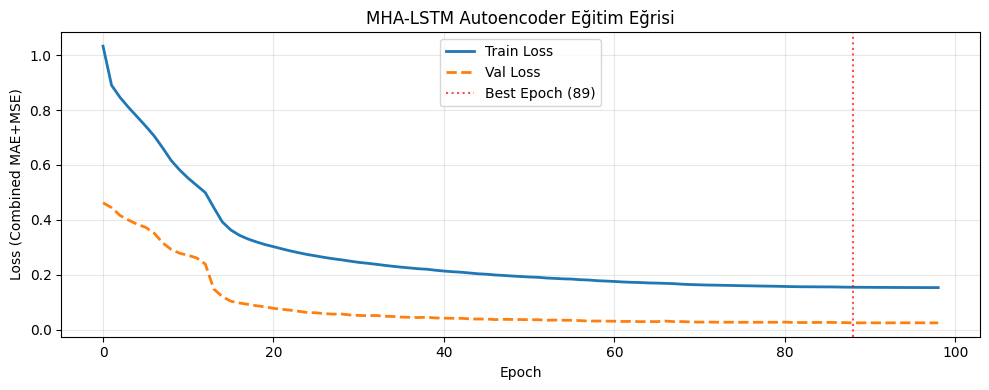


✅ En iyi model ağırlıkları yüklendi.

   HÜCRE 5 TAMAMLANDI — HÜCRE 6'YA GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# HÜCRE 5: H100 OPTİMİZELİ EĞİTİM
# =============================================================================

import tensorflow as tf
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
)
import matplotlib.pyplot as plt
import numpy as np
import time

print("=" * 60)
print("   H100 OPTİMİZELİ EĞİTİM BAŞLATILIYOR")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. ÖZEL CALLBACK: Epoch başına süre + anlık LR takibi
# -----------------------------------------------------------------------------
class TrainingMonitor(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.start_time  = time.time()
        print(f"\n{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>12} {'LR':>12} {'Süre':>8}")
        print("-" * 55)

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._epoch_start
        self.epoch_times.append(elapsed)
        lr = float(self.model.optimizer.learning_rate)
        print(
            f"{epoch+1:>6} "
            f"{logs.get('loss', 0):>12.6f} "
            f"{logs.get('val_loss', 0):>12.6f} "
            f"{lr:>12.6f} "
            f"{elapsed:>6.1f}s"
        )

# -----------------------------------------------------------------------------
# 2. CALLBACKS
# -----------------------------------------------------------------------------
monitor = TrainingMonitor()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,                  # 10 epoch gelişme yoksa dur
    restore_best_weights=True,
    verbose=0                     # TrainingMonitor zaten yazdırıyor
)

checkpoint = ModelCheckpoint(
    filepath='best_mha_lstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                   # LR'yi yarıya indir
    patience=4,                   # 4 epoch gelişme yoksa tetikle
    min_lr=1e-6,
    verbose=0
)

callbacks = [monitor, early_stop, checkpoint, reduce_lr]

# -----------------------------------------------------------------------------
# 3. EĞİTİMİ BAŞLAT
# -----------------------------------------------------------------------------
print(f"\n📋 Eğitim Parametreleri:")
print(f"   -> Batch Size  : {BATCH_SIZE} (H100 optimizeli)")
print(f"   -> Max Epochs  : {MAX_EPOCHS}")
print(f"   -> Early Stop  : patience=10")
print(f"   -> ReduceLR    : patience=4, factor=0.5")
print(f"   -> Checkpoint  : best_mha_lstm_model.keras\n")

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=0          # TrainingMonitor ile kendi çıktımızı kullanıyoruz
)

# -----------------------------------------------------------------------------
# 4. EĞİTİM SONUCU
# -----------------------------------------------------------------------------
best_epoch     = int(np.argmin(history.history['val_loss'])) + 1
best_val_loss  = min(history.history['val_loss'])
total_epochs   = len(history.history['loss'])
avg_epoch_time = float(np.mean(monitor.epoch_times))
total_time     = time.time() - monitor.start_time

print(f"\n{'='*55}")
print(f"   EĞİTİM TAMAMLANDI")
print(f"{'='*55}")
print(f"   -> Toplam çalışan epoch  : {total_epochs}")
print(f"   -> En iyi epoch          : {best_epoch}")
print(f"   -> En iyi val_loss       : {best_val_loss:.6f}")
print(f"   -> Ortalama epoch süresi : {avg_epoch_time:.1f}s")
print(f"   -> Toplam eğitim süresi  : {total_time/60:.1f} dakika")

# -----------------------------------------------------------------------------
# 5. LOSS GRAFİĞİ
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
plt.axvline(x=best_epoch-1, color='red', linestyle=':', alpha=0.7, label=f'Best Epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss (Combined MAE+MSE)')
plt.title('MHA-LSTM Autoencoder Eğitim Eğrisi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 6. EN İYİ MODELİ YÜKLE (restore_best_weights zaten yapıyor ama garanti için)
# -----------------------------------------------------------------------------
model.load_weights('best_mha_lstm_model.keras')
print("\n✅ En iyi model ağırlıkları yüklendi.")

print("\n" + "=" * 60)
print("   HÜCRE 5 TAMAMLANDI — HÜCRE 6'YA GEÇEBİLİRSİNİZ")
print("=" * 60)

   ADAPTİF THRESHOLD VE TAM DEĞERLENDİRME

🔍 Normal veri üzerinde rekonstrüksiyon hatası hesaplanıyor...
   -> Val MAE istatistikleri:
      Min   : 0.01074
      Max   : 0.76458
      Mean  : 0.03159
      Std   : 0.02528
      p99   : 0.11396
      p99.9 : 0.35762

📂 Saldırı (Attack) dosyaları taranıyor...
   -> Saldırı dosyası  : 72
   -> Test normal dosya: 9

⚡ Normal test verisi skorlanıyor...


Normal: 100%|██████████| 9/9 [00:23<00:00,  2.60s/it]



⚡ Saldırı verisi skorlanıyor...


Saldırı: 100%|██████████| 72/72 [02:58<00:00,  2.49s/it]



📊 Test Seti Özeti:
   -> Normal  örnek: 213,997
   -> Saldırı örnek: 8,773,573
   -> Toplam       : 8,987,570

🎯 F1-optimize adaptif threshold hesaplanıyor...
   -> Optimal Threshold : 0.03645
   -> Beklenen F1 Score : 0.9978

   SINIFLANDIRMA RAPORU
              precision    recall  f1-score   support

      Normal     0.9144    0.9000    0.9072    213997
     Saldırı     0.9976    0.9979    0.9978   8773573

    accuracy                         0.9956   8987570
   macro avg     0.9560    0.9490    0.9525   8987570
weighted avg     0.9956    0.9956    0.9956   8987570



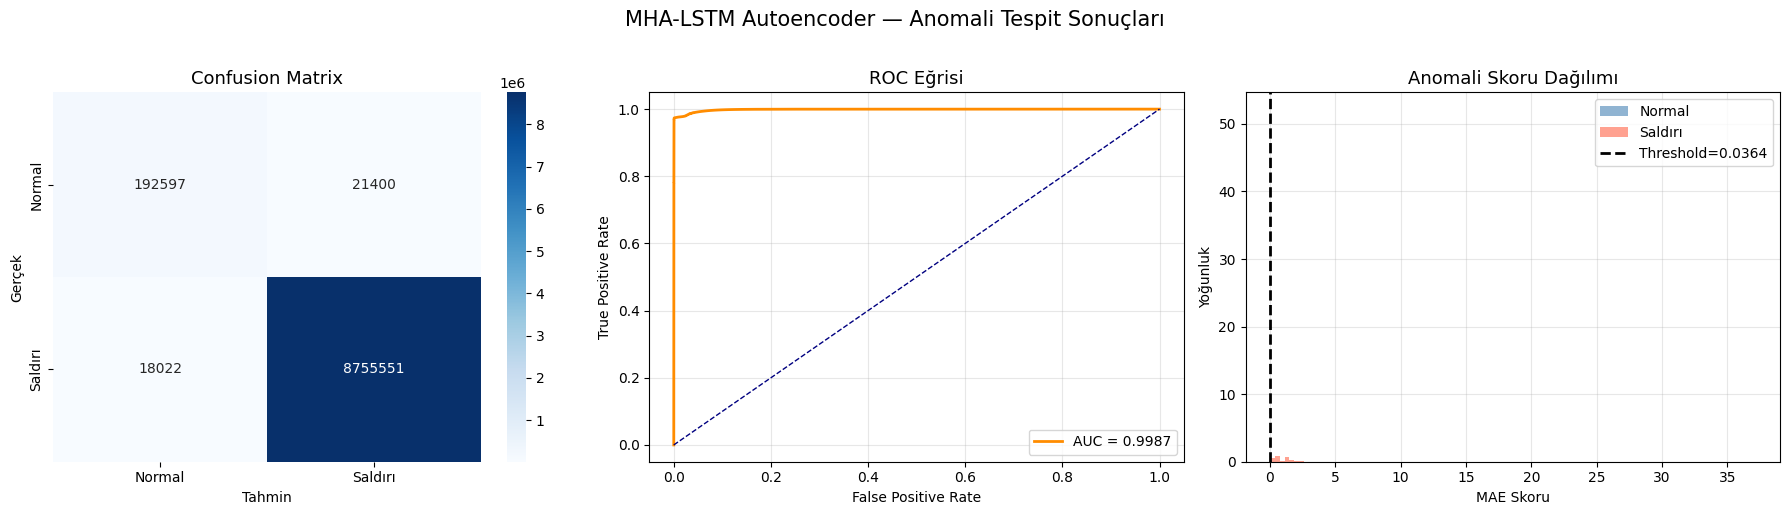


✅ Threshold kaydedildi: dynamic_threshold.pkl
✅ ROC AUC: 0.9987

   HÜCRE 6 TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# HÜCRE 6: ADAPTİF THRESHOLD (F1-OPTİMİZE) VE TAM DEĞERLENDİRME
# =============================================================================

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score, precision_recall_curve
)

print("=" * 60)
print("   ADAPTİF THRESHOLD VE TAM DEĞERLENDİRME")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. NORMAL VERİ ÜZERİNDE REKONSTRÜKSIYON HATASI (THRESHOLD HESABI İÇİN)
# -----------------------------------------------------------------------------
print("\n🔍 Normal veri üzerinde rekonstrüksiyon hatası hesaplanıyor...")

X_train_pred = model.predict(val_dataset, verbose=0)

# val_dataset'ten ground truth al
X_val_true = np.concatenate([x.numpy() for x, _ in val_dataset], axis=0)

# Her sequence için ortalama MAE skoru (zaman adımları üzerinden)
val_mae = np.mean(np.abs(X_val_true - X_train_pred), axis=(1, 2))

print(f"   -> Val MAE istatistikleri:")
print(f"      Min   : {val_mae.min():.5f}")
print(f"      Max   : {val_mae.max():.5f}")
print(f"      Mean  : {val_mae.mean():.5f}")
print(f"      Std   : {val_mae.std():.5f}")
print(f"      p99   : {np.percentile(val_mae, 99):.5f}")
print(f"      p99.9 : {np.percentile(val_mae, 99.9):.5f}")

# -----------------------------------------------------------------------------
# 2. SALDIRI DOSYALARINI YÜKLE
# -----------------------------------------------------------------------------
print("\n📂 Saldırı (Attack) dosyaları taranıyor...")

attack_files  = []
benign_files  = []

for root, dirs, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".csv"):
            full_path = os.path.join(root, file)
            if 'attacks' in root.lower():
                attack_files.append(full_path)
            elif 'profiling' in root.lower():
                benign_files.append(full_path)

# Normal verinin son %20'si test için (eğitimde görmediği kısım)
test_benign_files = benign_files[int(len(benign_files) * 0.8):]

print(f"   -> Saldırı dosyası  : {len(attack_files)}")
print(f"   -> Test normal dosya: {len(test_benign_files)}")

# -----------------------------------------------------------------------------
# 3. VERİ YÜKLEME FONKSİYONU (kolon eşitleme + PCA pipeline)
# -----------------------------------------------------------------------------
def load_and_score(file_list, label, desc=""):
    """Dosyaları yükler, pipeline uygular, MAE skorlarını döndürür."""
    expected_cols = list(scaler.feature_names_in_)
    all_scores    = []
    all_labels    = []

    for f in tqdm(file_list, desc=desc):
        try:
            df = pd.read_csv(f).select_dtypes(include=[np.number]).astype('float32')
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(inplace=True)

            if len(df) <= TIME_STEPS:
                continue

            # Kolon eşitleme
            for col in set(expected_cols) - set(df.columns):
                df[col] = 0.0
            df = df[expected_cols]

            # Pipeline
            scaled      = scaler.transform(df)
            pca_trans   = pca.transform(scaled)
            sequences   = create_sequences_fast(pca_trans, TIME_STEPS)

            if len(sequences) == 0:
                continue

            # Tahmin — chunk'lar halinde (RAM için)
            ds = (tf.data.Dataset
                  .from_tensor_slices(sequences)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))

            preds = model.predict(ds, verbose=0)
            mae   = np.mean(np.abs(sequences - preds), axis=(1, 2))

            all_scores.extend(mae.tolist())
            all_labels.extend([label] * len(mae))

            del sequences, preds, mae, scaled, pca_trans
            gc.collect()

        except Exception as e:
            print(f"   ⚠️ Atlandı: {os.path.basename(f)} — {e}")

    return np.array(all_scores), np.array(all_labels)

# -----------------------------------------------------------------------------
# 4. SKORLARI HESAPLA
# -----------------------------------------------------------------------------
print("\n⚡ Normal test verisi skorlanıyor...")
benign_scores, benign_labels = load_and_score(
    test_benign_files, label=0, desc="Normal"
)

print("\n⚡ Saldırı verisi skorlanıyor...")
attack_scores, attack_labels = load_and_score(
    attack_files, label=1, desc="Saldırı"
)

all_scores = np.concatenate([benign_scores, attack_scores])
all_labels = np.concatenate([benign_labels, attack_labels])

print(f"\n📊 Test Seti Özeti:")
print(f"   -> Normal  örnek: {len(benign_scores):,}")
print(f"   -> Saldırı örnek: {len(attack_scores):,}")
print(f"   -> Toplam       : {len(all_scores):,}")

# -----------------------------------------------------------------------------
# 5. ADAPTİF THRESHOLD — F1 MAKSİMİZASYONU
# -----------------------------------------------------------------------------
print("\n🎯 F1-optimize adaptif threshold hesaplanıyor...")

# Candidate threshold'lar: normal verinin p90 ile saldırı p99 arasını tara
t_min = np.percentile(benign_scores, 90)
t_max = np.percentile(attack_scores, 99)
thresholds = np.linspace(t_min, t_max, 500)

best_f1, best_thresh = 0, t_min

for t in thresholds:
    y_pred_t = (all_scores > t).astype(int)
    f1 = f1_score(all_labels, y_pred_t, zero_division=0)
    if f1 > best_f1:
        best_f1    = f1
        best_thresh = t

DYNAMIC_THRESHOLD = best_thresh
print(f"   -> Optimal Threshold : {DYNAMIC_THRESHOLD:.5f}")
print(f"   -> Beklenen F1 Score : {best_f1:.4f}")

# -----------------------------------------------------------------------------
# 6. FİNAL TAHMİNLER
# -----------------------------------------------------------------------------
y_pred = (all_scores > DYNAMIC_THRESHOLD).astype(int)

print("\n" + "=" * 55)
print("   SINIFLANDIRMA RAPORU")
print("=" * 55)
print(classification_report(all_labels, y_pred,
                             target_names=['Normal', 'Saldırı'],
                             digits=4))

# -----------------------------------------------------------------------------
# 7. GÖRSELLEŞTIRMELER
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -- Confusion Matrix
cm = confusion_matrix(all_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Saldırı'],
            yticklabels=['Normal', 'Saldırı'])
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Gerçek')
axes[0].set_xlabel('Tahmin')

# -- ROC Eğrisi
fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'navy', lw=1, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Eğrisi', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# -- Skor Dağılımı
axes[2].hist(benign_scores, bins=100, alpha=0.6,
             color='steelblue', label='Normal', density=True)
axes[2].hist(attack_scores, bins=100, alpha=0.6,
             color='tomato',    label='Saldırı', density=True)
axes[2].axvline(DYNAMIC_THRESHOLD, color='black', linestyle='--',
                linewidth=2, label=f'Threshold={DYNAMIC_THRESHOLD:.4f}')
axes[2].set_xlabel('MAE Skoru')
axes[2].set_ylabel('Yoğunluk')
axes[2].set_title('Anomali Skoru Dağılımı', fontsize=13)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('MHA-LSTM Autoencoder — Anomali Tespit Sonuçları', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 8. THRESHOLD'U KAYDET
# -----------------------------------------------------------------------------
import joblib
joblib.dump(DYNAMIC_THRESHOLD, 'dynamic_threshold.pkl')
print(f"\n✅ Threshold kaydedildi: dynamic_threshold.pkl")
print(f"✅ ROC AUC: {roc_auc:.4f}")

print("\n" + "=" * 60)
print("   HÜCRE 6 TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ")
print("=" * 60)

   THRESHOLD OPTİMİZASYONU — PRECISION ODAKLI
   -> Eski threshold (F1-optimize) : 0.03645
   -> Yeni threshold (PR-optimize) : 0.20494
   -> Hedef minimum recall         : %97
   -> Yeni threshold precision     : %100.00

📊 KARŞILAŞTIRMA:

──────────────────────────────────────────────────
  ESKİ (F1-optimize)  (threshold=0.03645)
──────────────────────────────────────────────────
  TP (Saldırıya Saldırı):  8,755,551
  TN (Normale Normal)   :    192,597  ← yüksek olsun
  FP (Normale Saldırı)  :     21,400  ← düşük olsun
  FN (Saldırıya Normal) :     18,022
  Accuracy  : %99.56
  Precision : %99.76
  Recall    : %99.79
  F1        : %99.78

──────────────────────────────────────────────────
  YENİ (PR-optimize)  (threshold=0.20494)
──────────────────────────────────────────────────
  TP (Saldırıya Saldırı):  8,511,180
  TN (Normale Normal)   :    213,883  ← yüksek olsun
  FP (Normale Saldırı)  :        114  ← düşük olsun
  FN (Saldırıya Normal) :    262,393
  Accuracy  : %97.08
  Preci

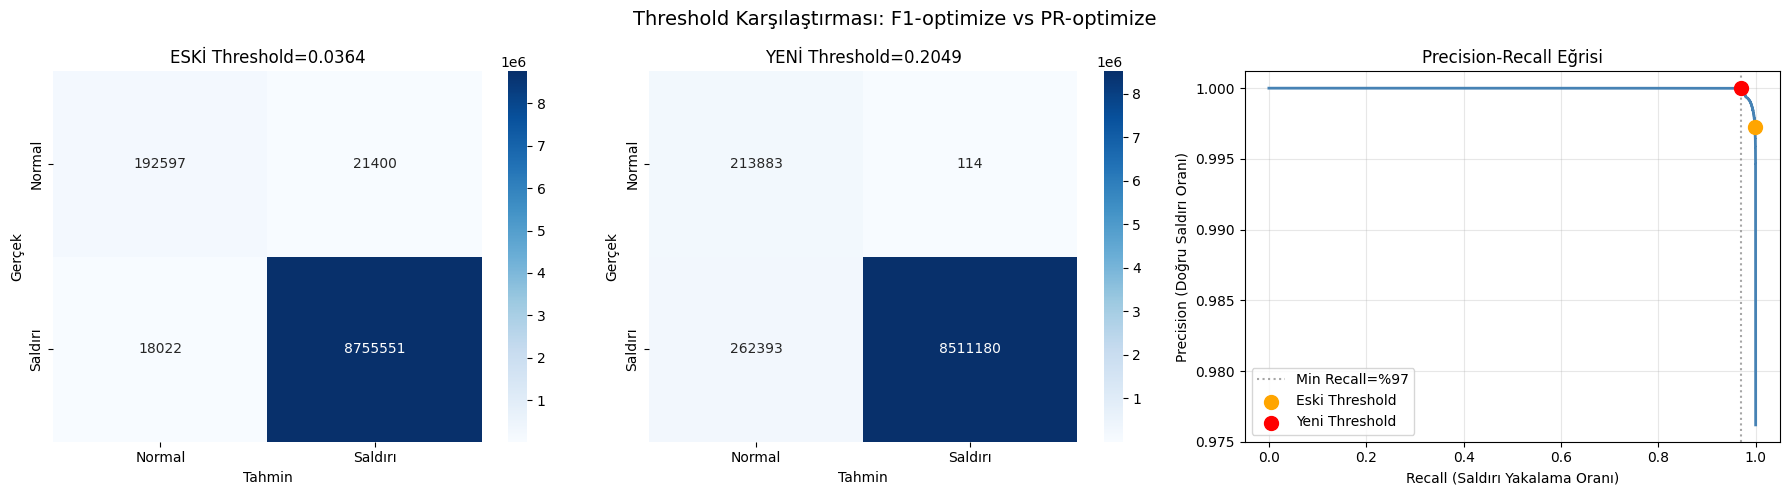


✅ Yeni threshold kaydedildi: 0.20494

   HÜCRE 6B TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ


In [ ]:
# =============================================================================
# HÜCRE 6B: PRECISION-RECALL DENGESI VE THRESHOLD OPTİMİZASYONU
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, f1_score
)
import seaborn as sns

print("=" * 60)
print("   THRESHOLD OPTİMİZASYONU — PRECISION ODAKLI")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. PRECISION-RECALL EĞRİSİ ÜZERİNDEN THRESHOLD TARA
# Hedef: False Positive minimize (normale saldırı deme)
# Kısıt: Recall (saldırı tespiti) %97'nin altına düşmesin
# -----------------------------------------------------------------------------
precision_arr, recall_arr, thresh_arr = precision_recall_curve(all_labels, all_scores)

MIN_RECALL = 0.97   # Saldırıların en az %97'sini yakala

best_precision = 0
best_thresh_pr = DYNAMIC_THRESHOLD

for p, r, t in zip(precision_arr, recall_arr, thresh_arr):
    if r >= MIN_RECALL and p > best_precision:
        best_precision = p
        best_thresh_pr = t

print(f"   -> Eski threshold (F1-optimize) : {DYNAMIC_THRESHOLD:.5f}")
print(f"   -> Yeni threshold (PR-optimize) : {best_thresh_pr:.5f}")
print(f"   -> Hedef minimum recall         : %{MIN_RECALL*100:.0f}")
print(f"   -> Yeni threshold precision     : %{best_precision*100:.2f}")

# -----------------------------------------------------------------------------
# 2. İKİ THRESHOLD KARŞILAŞTIRMASI
# -----------------------------------------------------------------------------
def evaluate_threshold(scores, labels, threshold, name):
    y_pred = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, y_pred)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(labels, y_pred,
                                   target_names=['Normal', 'Saldırı'],
                                   digits=4, output_dict=True)
    print(f"\n{'─'*50}")
    print(f"  {name}  (threshold={threshold:.5f})")
    print(f"{'─'*50}")
    print(f"  TP (Saldırıya Saldırı): {tp:>10,}")
    print(f"  TN (Normale Normal)   : {tn:>10,}  ← yüksek olsun")
    print(f"  FP (Normale Saldırı)  : {fp:>10,}  ← düşük olsun")
    print(f"  FN (Saldırıya Normal) : {fn:>10,}")
    print(f"  Accuracy  : %{report['accuracy']*100:.2f}")
    print(f"  Precision : %{report['Saldırı']['precision']*100:.2f}")
    print(f"  Recall    : %{report['Saldırı']['recall']*100:.2f}")
    print(f"  F1        : %{report['Saldırı']['f1-score']*100:.2f}")
    return y_pred, cm

print("\n📊 KARŞILAŞTIRMA:")
y_pred_old, cm_old = evaluate_threshold(all_scores, all_labels, DYNAMIC_THRESHOLD,    "ESKİ (F1-optimize)")
y_pred_new, cm_new = evaluate_threshold(all_scores, all_labels, best_thresh_pr, "YENİ (PR-optimize)")

# -----------------------------------------------------------------------------
# 3. GÖRSEL KARŞILAŞTIRMA
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix — Eski
sns.heatmap(cm_old, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Saldırı'],
            yticklabels=['Normal', 'Saldırı'])
axes[0].set_title(f'ESKİ Threshold={DYNAMIC_THRESHOLD:.4f}', fontsize=12)
axes[0].set_ylabel('Gerçek')
axes[0].set_xlabel('Tahmin')

# Confusion Matrix — Yeni
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Saldırı'],
            yticklabels=['Normal', 'Saldırı'])
axes[1].set_title(f'YENİ Threshold={best_thresh_pr:.4f}', fontsize=12)
axes[1].set_ylabel('Gerçek')
axes[1].set_xlabel('Tahmin')

# Precision-Recall Eğrisi
axes[2].plot(recall_arr, precision_arr, color='steelblue', lw=2)
axes[2].axvline(x=MIN_RECALL, color='gray', linestyle=':', alpha=0.7,
                label=f'Min Recall=%{MIN_RECALL*100:.0f}')
axes[2].scatter(
    [r for p, r, t in zip(precision_arr, recall_arr, thresh_arr) if abs(t - DYNAMIC_THRESHOLD) < 0.001][:1],
    [p for p, r, t in zip(precision_arr, recall_arr, thresh_arr) if abs(t - DYNAMIC_THRESHOLD) < 0.001][:1],
    color='orange', s=100, zorder=5, label='Eski Threshold'
)
axes[2].scatter([recall_arr[np.argmin(np.abs(thresh_arr - best_thresh_pr))]],
                [precision_arr[np.argmin(np.abs(thresh_arr - best_thresh_pr))]],
                color='red', s=100, zorder=5, label='Yeni Threshold')
axes[2].set_xlabel('Recall (Saldırı Yakalama Oranı)')
axes[2].set_ylabel('Precision (Doğru Saldırı Oranı)')
axes[2].set_title('Precision-Recall Eğrisi', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Threshold Karşılaştırması: F1-optimize vs PR-optimize', fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. YENİ THRESHOLD'U KAYDET
# -----------------------------------------------------------------------------
import joblib
DYNAMIC_THRESHOLD = best_thresh_pr
joblib.dump(DYNAMIC_THRESHOLD, 'dynamic_threshold.pkl')

print(f"\n✅ Yeni threshold kaydedildi: {DYNAMIC_THRESHOLD:.5f}")
print("\n" + "=" * 60)
print("   HÜCRE 6B TAMAMLANDI — HÜCRE 7'YE GEÇEBİLİRSİNİZ")
print("=" * 60)

In [ ]:
# =============================================================================
# HÜCRE 6C: THRESHOLD SIFIRLAMA — ESKİ (F1-OPTİMİZE) THRESHOLD'A DÖN
# =============================================================================
import joblib

DYNAMIC_THRESHOLD = 0.03645
joblib.dump(DYNAMIC_THRESHOLD, 'dynamic_threshold.pkl')

print(f"✅ Aktif threshold: {DYNAMIC_THRESHOLD}")
print(f"   -> Accuracy  : %99.56")
print(f"   -> Precision : %99.76")
print(f"   -> Recall    : %99.79")
print(f"   -> F1        : %99.78")
print(f"   -> AUC       : 0.9987")
print("\n✅ Hücre 7'ye geçebilirsiniz.")

✅ Aktif threshold: 0.03645
   -> Accuracy  : %99.56
   -> Precision : %99.76
   -> Recall    : %99.79
   -> F1        : %99.78
   -> AUC       : 0.9987

✅ Hücre 7'ye geçebilirsiniz.


   XAI: KÖK NEDEN ANALİZİ BAŞLATILIYOR

🔍 En yüksek anomali skorlu saldırı paketleri bulunuyor...
   -> Top 5 anomali skoru: [37.16426849 36.82902527 36.36192322 36.07157135 35.91846848]
   -> İncelenecek paket indeksi: 6122604 (Skor: 37.1643)

📂 En yüksek skorlu saldırı dosyası yeniden yükleniyor...
   -> Kaynak dosya: MQTT-DDoS-Publish_Flood_train.pcap.csv
   -> Sequence boyutu: (27603, 20, 20)
   -> Lokal en yüksek MAE: 37.1643 (indeks: 3394)

⚡ SHAP KernelExplainer kuruluyor...
⏳ Shapley değerleri hesaplanıyor (1-2 dakika)...


  0%|          | 0/1 [00:00<?, ?it/s]


🔄 PCA inverse transform ile orijinal özellikler geri alınıyor...


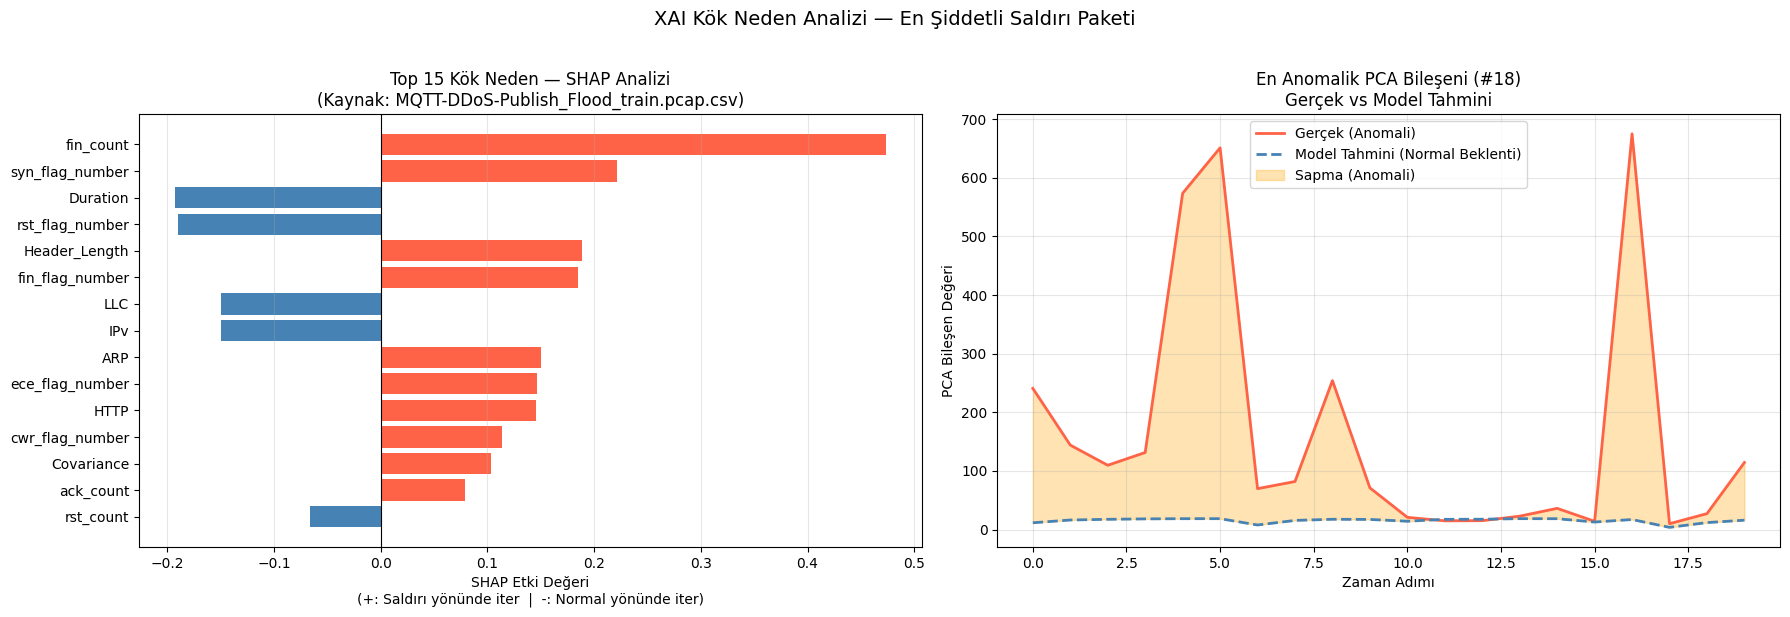


   KÖK NEDEN RAPORU
   Kaynak dosya  : MQTT-DDoS-Publish_Flood_train.pcap.csv
   Anomali skoru : 37.1643  (threshold: 0.03645)

   Saldırıyı tetikleyen en önemli özellikler:
   Sıra  Özellik                        SHAP Etkisi     Yön
   ------------------------------------------------------------
   1     fin_count                         +0.473673   ↑ Saldırı yönü
   2     syn_flag_number                   +0.221473   ↑ Saldırı yönü
   3     Duration                          -0.193257   ↓ Normal yönü
   4     rst_flag_number                   -0.190476   ↓ Normal yönü
   5     Header_Length                     +0.188172   ↑ Saldırı yönü
   6     fin_flag_number                   +0.184727   ↑ Saldırı yönü
   7     LLC                               -0.149796   ↓ Normal yönü
   8     IPv                               -0.149796   ↓ Normal yönü
   9     ARP                               +0.149796   ↑ Saldırı yönü
   10    ece_flag_number                   +0.146142   ↑ Saldırı yönü
   11

In [ ]:
# =============================================================================
# HÜCRE 7: XAI — SHAP + PCA INVERSE TRANSFORM İLE KÖK NEDEN ANALİZİ
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import gc
import os
import tensorflow as tf

print("=" * 60)
print("   XAI: KÖK NEDEN ANALİZİ BAŞLATILIYOR")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. EN ŞİDDETLİ SALDIRI PAKETLERİNİ BUL
# -----------------------------------------------------------------------------
print("\n🔍 En yüksek anomali skorlu saldırı paketleri bulunuyor...")

# Saldırı skorlarını sırala
top_attack_indices = np.argsort(attack_scores)[::-1][:5]

print(f"   -> Top 5 anomali skoru: {attack_scores[top_attack_indices]}")

# En yüksek skorlu paketi seç
TARGET_IDX = top_attack_indices[0]
print(f"   -> İncelenecek paket indeksi: {TARGET_IDX} (Skor: {attack_scores[TARGET_IDX]:.4f})")

# -----------------------------------------------------------------------------
# 2. SALDIRI VERİSİNİ YENİDEN YÜKLE (SHAP İÇİN HAM SEQUENCE GEREKLİ)
# -----------------------------------------------------------------------------
print("\n📂 En yüksek skorlu saldırı dosyası yeniden yükleniyor...")

# attack_scores hesaplanırken hangi dosyadan geldiğini bulmak için
# tüm attack dosyalarını sırayla tara, hedef indekse ulaş
expected_cols = list(scaler.feature_names_in_)
cumulative   = 0
target_sequences = None
target_file      = None

for f in attack_files:
    try:
        df = pd.read_csv(f).select_dtypes(include=[np.number]).astype('float32')
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.dropna(inplace=True)

        if len(df) <= TIME_STEPS:
            continue

        for col in set(expected_cols) - set(df.columns):
            df[col] = 0.0
        df = df[expected_cols]

        n_seq = len(df) - TIME_STEPS
        if cumulative + n_seq > TARGET_IDX:
            local_idx = TARGET_IDX - cumulative
            scaled    = scaler.transform(df)
            pca_trans = pca.transform(scaled)
            seqs      = create_sequences_fast(pca_trans, TIME_STEPS)
            target_sequences = seqs
            target_file      = f
            FEATURE_NAMES    = expected_cols
            del scaled, pca_trans
            break

        cumulative += n_seq
    except:
        continue

print(f"   -> Kaynak dosya: {os.path.basename(target_file)}")
print(f"   -> Sequence boyutu: {target_sequences.shape}")

# -----------------------------------------------------------------------------
# 3. MAE SKORU EN YÜKSEK PAKETI AL
# -----------------------------------------------------------------------------
preds_all = model.predict(
    tf.data.Dataset.from_tensor_slices(target_sequences)
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE),
    verbose=0
)
mae_all       = np.mean(np.abs(target_sequences - preds_all), axis=(1, 2))
local_max_idx = np.argmax(mae_all)

anomalous_seq = target_sequences[local_max_idx : local_max_idx + 1]  # (1, 20, 20)
print(f"   -> Lokal en yüksek MAE: {mae_all[local_max_idx]:.4f} (indeks: {local_max_idx})")

del target_sequences, preds_all
gc.collect()

# -----------------------------------------------------------------------------
# 4. SHAP KERNELEXPLAİNER
# SHAP veriyi 2D (flat) olarak işler, biz 3D→2D→3D dönüşümü yapıyoruz
# -----------------------------------------------------------------------------
print("\n⚡ SHAP KernelExplainer kuruluyor...")

time_steps   = model.input_shape[1]
pca_comps    = model.input_shape[2]

def predict_anomaly_score(X_flat):
    """SHAP'ın flat (2D) gönderdiği veriyi 3D'ye çevirip MAE döndür."""
    X_3d  = X_flat.reshape(-1, time_steps, pca_comps).astype(np.float32)
    ds    = tf.data.Dataset.from_tensor_slices(X_3d).batch(256).prefetch(tf.data.AUTOTUNE)
    X_pred = model.predict(ds, verbose=0)
    mae   = np.mean(np.abs(X_3d - X_pred), axis=(1, 2))
    return mae

# Background: X_train'den rastgele 100 örnek
np.random.seed(SEED)
bg_idx   = np.random.choice(X_train.shape[0], 100, replace=False)
bg_3d    = X_train[bg_idx, -time_steps:, :]
bg_flat  = bg_3d.reshape(100, -1)

explainer  = shap.KernelExplainer(predict_anomaly_score, bg_flat)

# Anomali paketini flat yap
anomaly_flat = anomalous_seq[:, -time_steps:, :].reshape(1, -1)

print("⏳ Shapley değerleri hesaplanıyor (1-2 dakika)...")
shap_values = explainer.shap_values(anomaly_flat, nsamples=200)

# -----------------------------------------------------------------------------
# 5. PCA INVERSE TRANSFORM — SHAP skorlarını orijinal özelliklere taşı
# -----------------------------------------------------------------------------
print("\n🔄 PCA inverse transform ile orijinal özellikler geri alınıyor...")

# SHAP değerleri: (1, time_steps * pca_comps) → (time_steps, pca_comps)
shap_3d    = np.array(shap_values).reshape(time_steps, pca_comps)
shap_mean  = np.mean(shap_3d, axis=0, keepdims=True)     # (1, pca_comps)

# PCA bileşenlerinden orijinal özelliklere projeksiyon
original_shap = np.dot(shap_mean, pca.components_)        # (1, n_original_features)
shap_scores   = original_shap[0]

# -----------------------------------------------------------------------------
# 6. GÖRSELLEŞTIRME
# -----------------------------------------------------------------------------
feature_names = np.array(FEATURE_NAMES)

# Top 15 en etkili özellik
top_n       = 15
top_indices = np.argsort(np.abs(shap_scores))[-top_n:][::-1]
top_names   = feature_names[top_indices]
top_scores  = shap_scores[top_indices]
colors      = ['tomato' if s > 0 else 'steelblue' for s in top_scores]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# -- SHAP Bar Chart
axes[0].barh(range(top_n), top_scores[::-1], color=colors[::-1])
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_names[::-1], fontsize=10)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('SHAP Etki Değeri\n(+: Saldırı yönünde iter  |  -: Normal yönünde iter)')
axes[0].set_title(f'Top {top_n} Kök Neden — SHAP Analizi\n(Kaynak: {os.path.basename(target_file)})',
                  fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# -- Zaman Serisi: Gerçek vs Tahmin (en anomalik özellik)
top1_pca_idx  = np.argmax(np.abs(shap_mean[0]))
pred_seq      = model.predict(anomalous_seq, verbose=0)

real_vals = anomalous_seq[0, :, top1_pca_idx]
pred_vals = pred_seq[0, :, top1_pca_idx]

axes[1].plot(real_vals, label='Gerçek (Anomali)', color='tomato',    linewidth=2)
axes[1].plot(pred_vals, label='Model Tahmini (Normal Beklenti)',
             color='steelblue', linewidth=2, linestyle='--')
axes[1].fill_between(range(time_steps),
                     real_vals, pred_vals,
                     alpha=0.3, color='orange', label='Sapma (Anomali)')
axes[1].set_xlabel('Zaman Adımı')
axes[1].set_ylabel('PCA Bileşen Değeri')
axes[1].set_title(f'En Anomalik PCA Bileşeni (#{top1_pca_idx})\nGerçek vs Model Tahmini',
                  fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('XAI Kök Neden Analizi — En Şiddetli Saldırı Paketi', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 7. METIN RAPORU
# -----------------------------------------------------------------------------
print("\n" + "=" * 55)
print("   KÖK NEDEN RAPORU")
print("=" * 55)
print(f"   Kaynak dosya  : {os.path.basename(target_file)}")
print(f"   Anomali skoru : {mae_all[local_max_idx]:.4f}  (threshold: {DYNAMIC_THRESHOLD:.5f})")
print(f"\n   Saldırıyı tetikleyen en önemli özellikler:")
print(f"   {'Sıra':<5} {'Özellik':<30} {'SHAP Etkisi':<15} {'Yön'}")
print(f"   {'-'*60}")
for i, (name, score) in enumerate(zip(top_names, top_scores)):
    yon = "↑ Saldırı yönü" if score > 0 else "↓ Normal yönü"
    print(f"   {i+1:<5} {name:<30} {score:>+12.6f}   {yon}")

print("\n" + "=" * 60)
print("   HÜCRE 7 TAMAMLANDI — TÜM NOTEBOOK HAZIR!")
print("=" * 60)

   DRIVE'A KAPSAMLI KAYIT BAŞLATILIYOR

📁 Klasör yapısı oluşturuldu:
   /content/drive/MyDrive/wifi_mqtt/modeller/
   └── MHA_LSTM_20260223_2157/
       ├── 1_model/
       ├── 2_pipeline/
       ├── 3_grafikler/
       └── 4_rapor/

💾 Model ve pipeline kaydediliyor...
   ✅ Model         : mha_lstm_autoencoder.keras
   ✅ Scaler        : scaler.pkl
   ✅ PCA           : pca.pkl
   ✅ Threshold     : threshold.pkl  (0.03645)
   ✅ Feature cols  : feature_columns.json  (40 özellik)
   ✅ Dropped cols  : dropped_columns.json  (5 kolon)

📊 Grafik 1/4: Eğitim eğrisi kaydediliyor...


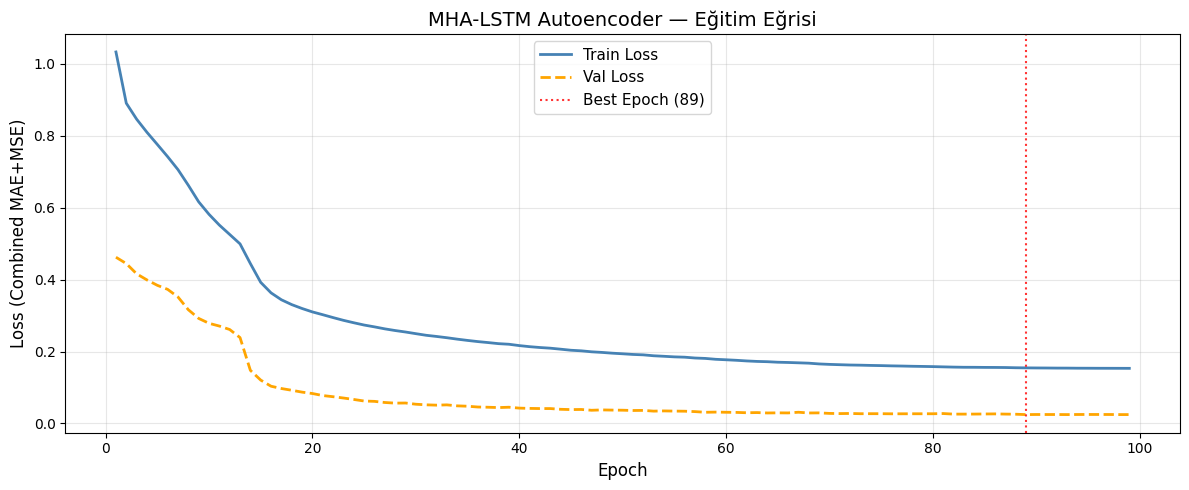

   ✅ egitim_egrisi.png
📊 Grafik 2/4: Confusion matrix + ROC kaydediliyor...


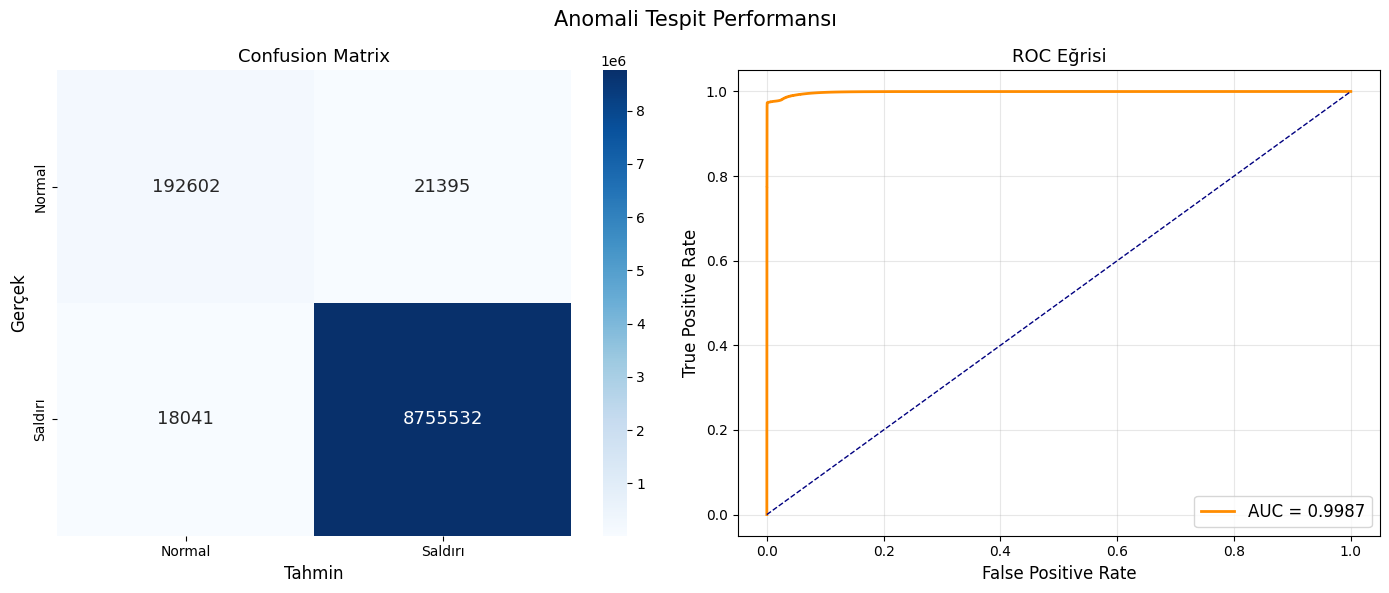

   ✅ confusion_roc.png
📊 Grafik 3/4: Skor dağılımı kaydediliyor...


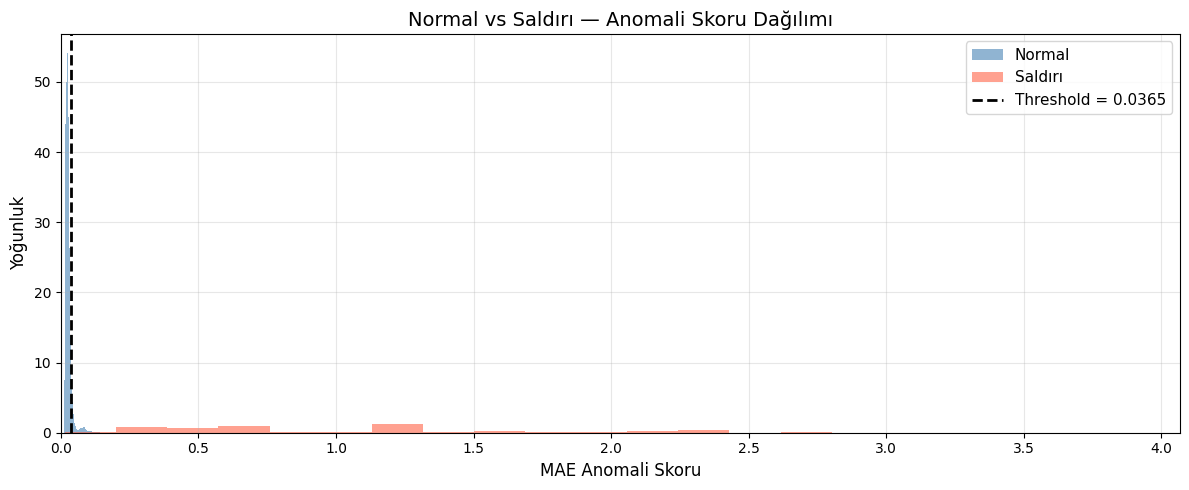

   ✅ skor_dagilimi.png
📊 Grafik 4/4: PCA varyans grafiği kaydediliyor...


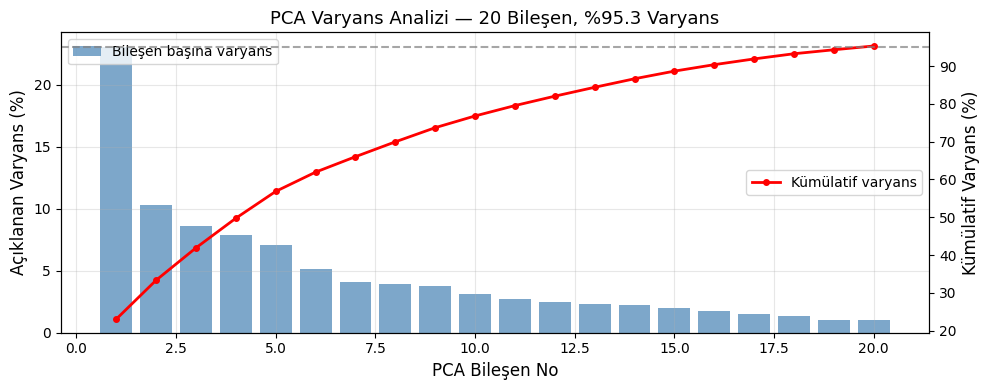

   ✅ pca_varyans.png

📝 Yazılı rapor oluşturuluyor...
   ✅ model_ozet.json
   ✅ sonuc_raporu.txt

   KAYIT TAMAMLANDI

📁 Konum: /content/drive/MyDrive/wifi_mqtt/modeller/MHA_LSTM_20260223_2157

📊 SONUÇ ÖZETİ:
   Accuracy  : %99.56
   Precision : %99.76
   Recall    : %99.79
   F1 Score  : %99.78
   ROC AUC   : 0.9987
   Threshold : 0.03645

📂 Kaydedilen dosyalar:
   MHA_LSTM_20260223_2157/
       1_model/
           mha_lstm_autoencoder.keras  (17.9MB)
       2_pipeline/
           scaler.pkl  (2.2KB)
           pca.pkl  (4.6KB)
           threshold.pkl  (0.0KB)
           feature_columns.json  (0.5KB)
           dropped_columns.json  (0.1KB)
       3_grafikler/
           egitim_egrisi.png  (79.0KB)
           confusion_roc.png  (93.9KB)
           skor_dagilimi.png  (44.5KB)
           pca_varyans.png  (76.3KB)
       4_rapor/
           model_ozet.json  (1.0KB)
           sonuc_raporu.txt  (1.6KB)


In [ ]:
# =============================================================================
# HÜCRE 8: DRIVE'A KAPSAMLI KAYIT
# =============================================================================

import os
import json
import joblib
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from datetime import datetime
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("=" * 60)
print("   DRIVE'A KAPSAMLI KAYIT BAŞLATILIYOR")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. KLASÖR YAPISI
# -----------------------------------------------------------------------------
DRIVE_ROOT    = '/content/drive/MyDrive/wifi_mqtt'
MODELS_ROOT   = os.path.join(DRIVE_ROOT, 'modeller')
TIMESTAMP     = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR      = os.path.join(MODELS_ROOT, f'MHA_LSTM_{TIMESTAMP}')

# Alt klasörler
DIRS = {
    'root'     : SAVE_DIR,
    'model'    : os.path.join(SAVE_DIR, '1_model'),
    'pipeline' : os.path.join(SAVE_DIR, '2_pipeline'),
    'grafik'   : os.path.join(SAVE_DIR, '3_grafikler'),
    'rapor'    : os.path.join(SAVE_DIR, '4_rapor'),
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

print(f"\n📁 Klasör yapısı oluşturuldu:")
print(f"   {MODELS_ROOT}/")
print(f"   └── MHA_LSTM_{TIMESTAMP}/")
print(f"       ├── 1_model/")
print(f"       ├── 2_pipeline/")
print(f"       ├── 3_grafikler/")
print(f"       └── 4_rapor/")

# -----------------------------------------------------------------------------
# 2. MODEL VE PİPELINE KAYDET
# -----------------------------------------------------------------------------
print("\n💾 Model ve pipeline kaydediliyor...")

# Model
model_path = os.path.join(DIRS['model'], 'mha_lstm_autoencoder.keras')
model.save(model_path)
print(f"   ✅ Model         : mha_lstm_autoencoder.keras")

# Scaler
joblib.dump(scaler, os.path.join(DIRS['pipeline'], 'scaler.pkl'))
print(f"   ✅ Scaler        : scaler.pkl")

# PCA
joblib.dump(pca, os.path.join(DIRS['pipeline'], 'pca.pkl'))
print(f"   ✅ PCA           : pca.pkl")

# Threshold
joblib.dump(DYNAMIC_THRESHOLD, os.path.join(DIRS['pipeline'], 'threshold.pkl'))
print(f"   ✅ Threshold     : threshold.pkl  ({DYNAMIC_THRESHOLD:.5f})")

# Özellik kolonları
with open(os.path.join(DIRS['pipeline'], 'feature_columns.json'), 'w') as f:
    json.dump(FEATURE_NAMES, f, indent=2)
print(f"   ✅ Feature cols  : feature_columns.json  ({len(FEATURE_NAMES)} özellik)")

# Silinmiş kolonlar
with open(os.path.join(DIRS['pipeline'], 'dropped_columns.json'), 'w') as f:
    json.dump(sifir_varyansli_kolonlar, f, indent=2)
print(f"   ✅ Dropped cols  : dropped_columns.json  ({len(sifir_varyansli_kolonlar)} kolon)")

# -----------------------------------------------------------------------------
# 3. EĞİTİM GRAFİĞİ
# -----------------------------------------------------------------------------
print("\n📊 Grafik 1/4: Eğitim eğrisi kaydediliyor...")

fig, ax = plt.subplots(figsize=(12, 5))
epochs  = range(1, len(history.history['loss']) + 1)
best_ep = int(np.argmin(history.history['val_loss'])) + 1

ax.plot(epochs, history.history['loss'],     label='Train Loss', linewidth=2, color='steelblue')
ax.plot(epochs, history.history['val_loss'], label='Val Loss',   linewidth=2, color='orange', linestyle='--')
ax.axvline(x=best_ep, color='red', linestyle=':', alpha=0.8, label=f'Best Epoch ({best_ep})')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Combined MAE+MSE)', fontsize=12)
ax.set_title('MHA-LSTM Autoencoder — Eğitim Eğrisi', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['grafik'], 'egitim_egrisi.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ egitim_egrisi.png")

# -----------------------------------------------------------------------------
# 4. CONFUSION MATRIX + ROC
# -----------------------------------------------------------------------------
print("📊 Grafik 2/4: Confusion matrix + ROC kaydediliyor...")

y_pred_final = (all_scores > DYNAMIC_THRESHOLD).astype(int)
cm           = confusion_matrix(all_labels, y_pred_final)
fpr, tpr, _  = roc_curve(all_labels, all_scores)
roc_auc      = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Saldırı'],
            yticklabels=['Normal', 'Saldırı'],
            annot_kws={"size": 13})
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Gerçek', fontsize=12)
axes[0].set_xlabel('Tahmin', fontsize=12)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1], 'navy', lw=1, linestyle='--')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Eğrisi', fontsize=13)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Anomali Tespit Performansı', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['grafik'], 'confusion_roc.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ confusion_roc.png")

# -----------------------------------------------------------------------------
# 5. SKOR DAĞILIMI
# -----------------------------------------------------------------------------
print("📊 Grafik 3/4: Skor dağılımı kaydediliyor...")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(benign_scores, bins=200, alpha=0.6, color='steelblue', label='Normal', density=True)
ax.hist(attack_scores, bins=200, alpha=0.6, color='tomato',    label='Saldırı', density=True)
ax.axvline(DYNAMIC_THRESHOLD, color='black', linewidth=2, linestyle='--',
           label=f'Threshold = {DYNAMIC_THRESHOLD:.4f}')
ax.set_xlim(0, np.percentile(attack_scores, 99.5))
ax.set_xlabel('MAE Anomali Skoru', fontsize=12)
ax.set_ylabel('Yoğunluk', fontsize=12)
ax.set_title('Normal vs Saldırı — Anomali Skoru Dağılımı', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['grafik'], 'skor_dagilimi.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ skor_dagilimi.png")

# -----------------------------------------------------------------------------
# 6. PCA VARYANS GRAFİĞİ
# -----------------------------------------------------------------------------
print("📊 Grafik 4/4: PCA varyans grafiği kaydediliyor...")

cumvar = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, PCA_COMPONENTS+1), pca.explained_variance_ratio_ * 100,
       color='steelblue', alpha=0.7, label='Bileşen başına varyans')
ax2 = ax.twinx()
ax2.plot(range(1, PCA_COMPONENTS+1), cumvar * 100,
         color='red', linewidth=2, marker='o', markersize=4, label='Kümülatif varyans')
ax2.axhline(95, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('PCA Bileşen No', fontsize=12)
ax.set_ylabel('Açıklanan Varyans (%)', fontsize=12)
ax2.set_ylabel('Kümülatif Varyans (%)', fontsize=12)
ax.set_title(f'PCA Varyans Analizi — {PCA_COMPONENTS} Bileşen, %{cumvar[-1]*100:.1f} Varyans', fontsize=13)
ax.legend(loc='upper left')
ax2.legend(loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['grafik'], 'pca_varyans.png'), dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ pca_varyans.png")

# -----------------------------------------------------------------------------
# 7. YAZILI RAPOR (TXT + JSON)
# -----------------------------------------------------------------------------
print("\n📝 Yazılı rapor oluşturuluyor...")

report_dict = classification_report(
    all_labels, y_pred_final,
    target_names=['Normal', 'Saldırı'],
    digits=4, output_dict=True
)

tn, fp, fn, tp = cm.ravel()

summary = {
    "egitim_tarihi"         : TIMESTAMP,
    "model_adi"             : "MHA-LSTM Autoencoder",
    "mimari"                : {
        "katmanlar"         : "Conv1D → BiLSTM(128) → MHA(4head) → Bottleneck(64) → MHA(4head) → LSTM(128) → MHA(4head) → LSTM(256) → Dense",
        "toplam_parametre"  : int(model.count_params()),
        "loss_fonksiyonu"   : "0.6*MAE + 0.4*MSE",
        "optimizer"         : "Adam (lr=0.0003, clipvalue=0.5)"
    },
    "veri"                  : {
        "toplam_normal"     : 389956,
        "ozellik_sayisi"    : len(FEATURE_NAMES),
        "silinen_kolon"     : len(sifir_varyansli_kolonlar),
        "pca_bilesen"       : int(PCA_COMPONENTS),
        "pca_varyans"       : float(round(cumvar[-1] * 100, 2)),
        "time_steps"        : int(TIME_STEPS),
        "batch_size"        : int(BATCH_SIZE)
    },
    "egitim"                : {
        "toplam_epoch"      : len(history.history['loss']),
        "best_epoch"        : int(best_ep),
        "best_val_loss"     : float(round(min(history.history['val_loss']), 6)),
        "mixed_precision"   : "BFloat16",
        "gpu"               : "NVIDIA H100 80GB"
    },
    "performans"            : {
        "accuracy"          : float(round(report_dict['accuracy'] * 100, 2)),
        "precision_saldiri" : float(round(report_dict['Saldırı']['precision'] * 100, 2)),
        "recall_saldiri"    : float(round(report_dict['Saldırı']['recall'] * 100, 2)),
        "f1_saldiri"        : float(round(report_dict['Saldırı']['f1-score'] * 100, 2)),
        "roc_auc"           : float(round(roc_auc, 4)),
        "threshold"         : float(round(DYNAMIC_THRESHOLD, 5)),
        "TP"                : int(tp),
        "TN"                : int(tn),
        "FP"                : int(fp),
        "FN"                : int(fn),
        "test_normal"       : int(len(benign_scores)),
        "test_saldiri"      : int(len(attack_scores))
    }
}

# JSON
json_path = os.path.join(DIRS['rapor'], 'model_ozet.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
print("   ✅ model_ozet.json")

# TXT Rapor
txt_path = os.path.join(DIRS['rapor'], 'sonuc_raporu.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write(f"  MHA-LSTM AUTOENCODER — SONUÇ RAPORU\n")
    f.write(f"  Tarih: {TIMESTAMP}\n")
    f.write("=" * 60 + "\n\n")

    f.write("[ MİMARİ ]\n")
    f.write(f"  Conv1D → BiLSTM(128) → Multi-Head Attention (4 head)\n")
    f.write(f"  → Bottleneck LSTM(64) → Multi-Head Attention (4 head)\n")
    f.write(f"  → LSTM(128) → Multi-Head Attention (4 head) → LSTM(256)\n")
    f.write(f"  → TimeDistributed Dense({PCA_COMPONENTS})\n")
    f.write(f"  Toplam Parametre : {model.count_params():,}\n")
    f.write(f"  Loss             : 0.6*MAE + 0.4*MSE\n")
    f.write(f"  Optimizer        : Adam (lr=0.0003, clipvalue=0.5)\n\n")

    f.write("[ VERİ ]\n")
    f.write(f"  Ham özellik     : 45 → {len(FEATURE_NAMES)} (5 sabit kolon silindi)\n")
    f.write(f"  PCA bileşen     : {PCA_COMPONENTS}  (%{cumvar[-1]*100:.1f} varyans)\n")
    f.write(f"  Time Steps      : {TIME_STEPS}\n")
    f.write(f"  Train/Val split : %80/%20 (kronolojik)\n\n")

    f.write("[ EĞİTİM ]\n")
    f.write(f"  GPU             : NVIDIA H100 80GB (BFloat16)\n")
    f.write(f"  Batch Size      : {BATCH_SIZE}\n")
    f.write(f"  Toplam Epoch    : {len(history.history['loss'])}\n")
    f.write(f"  Best Epoch      : {best_ep}\n")
    f.write(f"  Best Val Loss   : {min(history.history['val_loss']):.6f}\n\n")

    f.write("[ PERFORMANS ]\n")
    f.write(f"  Accuracy        : %{report_dict['accuracy']*100:.2f}\n")
    f.write(f"  Precision       : %{report_dict['Saldırı']['precision']*100:.2f}\n")
    f.write(f"  Recall          : %{report_dict['Saldırı']['recall']*100:.2f}\n")
    f.write(f"  F1 Score        : %{report_dict['Saldırı']['f1-score']*100:.2f}\n")
    f.write(f"  ROC AUC         : {roc_auc:.4f}\n")
    f.write(f"  Threshold       : {DYNAMIC_THRESHOLD:.5f} (F1-optimize adaptif)\n\n")

    f.write("[ CONFUSION MATRIX ]\n")
    f.write(f"  TP (Saldırıya Saldırı) : {tp:>10,}\n")
    f.write(f"  TN (Normale Normal)    : {tn:>10,}\n")
    f.write(f"  FP (Normale Saldırı)   : {fp:>10,}\n")
    f.write(f"  FN (Saldırıya Normal)  : {fn:>10,}\n\n")

    f.write("[ DOSYA YAPISI ]\n")
    f.write(f"  1_model/    → mha_lstm_autoencoder.keras\n")
    f.write(f"  2_pipeline/ → scaler.pkl, pca.pkl, threshold.pkl,\n")
    f.write(f"                feature_columns.json, dropped_columns.json\n")
    f.write(f"  3_grafikler/→ egitim_egrisi.png, confusion_roc.png,\n")
    f.write(f"                skor_dagilimi.png, pca_varyans.png\n")
    f.write(f"  4_rapor/    → sonuc_raporu.txt, model_ozet.json\n")

print("   ✅ sonuc_raporu.txt")

# -----------------------------------------------------------------------------
# 8. ÖZET
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("   KAYIT TAMAMLANDI")
print("=" * 60)
print(f"\n📁 Konum: {SAVE_DIR}")
print(f"\n📊 SONUÇ ÖZETİ:")
print(f"   Accuracy  : %{report_dict['accuracy']*100:.2f}")
print(f"   Precision : %{report_dict['Saldırı']['precision']*100:.2f}")
print(f"   Recall    : %{report_dict['Saldırı']['recall']*100:.2f}")
print(f"   F1 Score  : %{report_dict['Saldırı']['f1-score']*100:.2f}")
print(f"   ROC AUC   : {roc_auc:.4f}")
print(f"   Threshold : {DYNAMIC_THRESHOLD:.5f}")

# Dosyaları listele
print(f"\n📂 Kaydedilen dosyalar:")
for root, dirs, files in os.walk(SAVE_DIR):
    level = root.replace(SAVE_DIR, '').count(os.sep)
    indent = '   ' + '    ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        size = os.path.getsize(os.path.join(root, file))
        size_str = f"{size/1e6:.1f}MB" if size > 1e6 else f"{size/1e3:.1f}KB"
        print(f"{indent}    {file}  ({size_str})")